# P02 Banking EDA ? NexBank
## Interactive Exploration Notebook

This notebook uses the previously attached banking processed data:

`C:\banking-etl-pipeline\data\processed\processed-data.csv`

It explores fraud patterns, customer segment behavior, chi-square significance, and transaction anomalies.

**Business questions**
1. Do fraudulent transactions cluster by merchant category, channel, or time period?
2. How do transaction amounts and fraud rates differ across customer segments?
3. Is fraud statistically independent of merchant category?
4. Which transactions are unusual by amount, and which fraud rows have normal-looking amounts?


In [1]:
# Cell 1: Imports and project setup
import pathlib
import sys

PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / "config.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ATTACHED_DATA_PATH = pathlib.Path(r"C:\banking-etl-pipeline\data\processed\processed-data.csv")

try:
    from config import REPORTS_DIR
except ImportError:
    REPORTS_DIR = PROJECT_ROOT / "reports"

# Primary source is the banking processed data attached earlier.
# Fallback only helps if the notebook is moved to another machine.
DATA_PATH = ATTACHED_DATA_PATH if ATTACHED_DATA_PATH.exists() else PROJECT_ROOT / "data" / "processed-data.csv"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using data file: {DATA_PATH}")


Using data file: C:\banking-etl-pipeline\data\processed\processed-data.csv


In [2]:
# Cell 2: Load processed banking data
df = pd.read_csv(DATA_PATH, low_memory=False)

# Normalize core data types used throughout the notebook.
if "is_fraud" in df.columns:
    df["is_fraud"] = df["is_fraud"].astype(str).str.lower().isin(["true", "1", "yes", "y"])

for col in ["transaction_date", "alert_date", "opened_date", "customer_since", "date_of_birth"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

if "transaction_hour" not in df.columns and "transaction_time" in df.columns:
    df["transaction_hour"] = pd.to_datetime(df["transaction_time"], format="%H:%M", errors="coerce").dt.hour

amount_col = "transaction_value" if "transaction_value" in df.columns else "amount"

print("=" * 60)
print("NEXBANK DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Unique transactions: {df['transaction_id'].nunique():,}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Fraud rows: {int(df['is_fraud'].sum()):,}")
print(f"Fraud rate: {df['is_fraud'].mean():.2%}")
df.head()


NEXBANK DATASET OVERVIEW
Rows: 86,578
Columns: 58
Unique transactions: 50,006
Unique customers: 7,982
Fraud rows: 2,755
Fraud rate: 3.18%


,transaction_id,account_id,customer_id,transaction_date,transaction_time,amount,transaction_type,merchant_name,merchant_category,channel,...,has_fraud_alert,balance_before_estimate,loan_remaining_pct,credit_score_band,transaction_year,transaction_month,_source_system,_processed_at,_pipeline_version,transaction_hour
0,3923,17,4518,2024-12-31,22:45,32.47,ATM,Target,Restaurant,Mobile,...,False,40070.37,0.00,Poor,2024,12,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,22
1,3005,4646,3820,2024-12-31,12:00,125.82,Payment,Shell,Restaurant,Online,...,False,34384.99,66.00,Fair,2024,12,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,12
2,203,4702,651,2024-12-31,14:33,277.15,Debit,Target,Gas,ATM,...,False,25786.55,89.82,Poor,2024,12,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,14
3,3752,1358,1137,2024-12-31,08:38,89.45,Debit,Amazon,Travel,Branch,...,False,24309.21,42.84,Fair,2024,12,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,8
4,6325,1300,4723,2024-12-31,01:03,26.12,Transfer,Walmart,Utilities,Online,...,False,43817.95,80.27,Very Good,2024,12,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,1


In [3]:
# Cell 3: Missing values and descriptive statistics
missing = (
    df.isna().sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)

display(missing.head(20))
display(df.select_dtypes(include="number").describe().round(2).T)


,missing_count,missing_pct
alert_id,81286,93.89
alert_date,81286,93.89
loan_id,11144,12.87


,count,mean,std,min,25%,50%,75%,max
transaction_id,86578.0,24997.16,14435.77,1.00,12538.00,24946.50,37508.00,50006.00
account_id,86578.0,4982.56,2889.37,1.00,2469.00,4987.00,7481.00,10000.00
customer_id,86578.0,3987.53,2309.69,1.00,2017.00,3973.50,5990.00,8000.00
amount,86578.0,250.05,9004.27,-469.31,19.82,54.41,150.77,999999.00
balance_after,86578.0,24976.50,14471.48,0.44,12442.53,24972.64,37516.72,49999.71
credit_score,86578.0,571.47,157.73,300.00,431.00,572.00,705.00,850.00
balance,86578.0,123890.69,72717.56,-999999.00,61857.50,125118.94,185221.83,249980.73
account_interest_rate,86578.0,0.02,0.01,0.00,0.01,0.02,0.03,0.04
loan_id,75434.0,5977.23,3461.30,1.00,2979.00,5963.00,8967.00,12000.00
principal,86578.0,222653.80,159219.85,0.00,73012.42,221625.64,362847.41,499984.39


## Fraud Patterns
Fraud concentration is compared by merchant category, channel, transaction hour, month, and customer segment.


In [5]:
# Cell 4: Fraud patterns by business dimensions
def fraud_table(data, group_col):
    table = data.groupby(group_col, dropna=False).agg(
        transaction_count=("transaction_id", "count"),
        fraud_count=("is_fraud", "sum"),
        avg_amount=(amount_col, "mean"),
        total_amount=(amount_col, "sum"),
    )
    table["fraud_rate"] = table["fraud_count"] / table["transaction_count"]
    return table.sort_values(["fraud_rate", "fraud_count"], ascending=False).reset_index()

fraud_tables = {}
for col in ["merchant_category", "channel", "transaction_hour", "transaction_month", "segment"]:
    if col in df.columns:
        fraud_tables[col] = fraud_table(df, col)
        print(f"Top fraud concentrations by {col}:")
        display(fraud_tables[col].head(10))


Top fraud concentrations by merchant_category:


,merchant_category,transaction_count,fraud_count,avg_amount,total_amount,fraud_rate
0,Grocery,8846,328,158.913916,1405752.50,0.037079
1,Online,9234,319,269.461398,2488206.55,0.034546
2,Restaurant,9451,320,169.102518,1598187.90,0.033859
3,ATM,9104,303,167.827242,1527899.21,0.033282
4,Utilities,9160,291,380.327806,3483802.70,0.031769
5,Gas,9229,286,178.993465,1651930.69,0.030989
6,Entertainment,9203,280,399.079660,3672730.11,0.030425
7,Travel,9122,266,181.824603,1658604.03,0.029160
8,Healthcare,8971,260,382.968935,3435614.32,0.028982
9,Unknown,4258,102,171.264627,729244.78,0.023955


Top fraud concentrations by channel:


,channel,transaction_count,fraud_count,avg_amount,total_amount,fraud_rate
0,ATM,16736,553,165.053890,2762341.90,0.033043
1,Online,16607,542,414.658342,6886231.08,0.032637
2,POS,16912,543,349.414944,5909305.54,0.032107
3,Branch,16845,532,163.008267,2745874.26,0.031582
4,Unknown,2615,79,164.525908,430235.25,0.030210
5,Mobile,16863,506,173.040667,2917984.76,0.030007


Top fraud concentrations by transaction_hour:


,transaction_hour,transaction_count,fraud_count,avg_amount,total_amount,fraud_rate
0,3,3595,150,170.116743,611569.69,0.041725
1,14,3688,152,158.354227,584010.39,0.041215
2,1,3532,143,743.937378,2627586.82,0.040487
3,10,3745,146,149.107466,558407.46,0.038985
4,18,3504,119,176.252175,617587.62,0.033961
5,12,3601,119,726.468956,2616014.71,0.033046
6,17,3694,122,165.059407,609729.45,0.033027
7,22,3577,118,718.118510,2568709.91,0.032989
8,0,3663,119,161.044032,589904.29,0.032487
9,2,3435,107,166.871374,573203.17,0.031150


Top fraud concentrations by transaction_month:


,transaction_month,transaction_count,fraud_count,avg_amount,total_amount,fraud_rate
0,5,7409,261,444.940208,3296562.00,0.035227
1,10,7393,255,152.462436,1127154.79,0.034492
2,6,7134,242,448.494973,3199563.14,0.033922
3,11,7249,243,296.917037,2152351.60,0.033522
4,1,7103,237,165.607239,1176308.22,0.033366
5,12,7278,235,171.538864,1248459.85,0.032289
6,2,6747,211,172.079136,1161017.93,0.031273
7,9,7092,218,177.812971,1261049.59,0.030739
8,4,7176,219,177.586264,1274359.03,0.030518
9,8,7464,223,444.668520,3319005.83,0.029877


Top fraud concentrations by segment:


,segment,transaction_count,fraud_count,avg_amount,total_amount,fraud_rate
0,Premium,17579,588,162.578995,2857976.15,0.033449
1,Retail,16969,544,174.899913,2967876.63,0.032058
2,Senior,17554,560,169.852227,2981585.99,0.031902
3,Student,17905,554,337.813424,6048549.35,0.030941
4,Business,16571,509,410.113130,6795984.67,0.030716


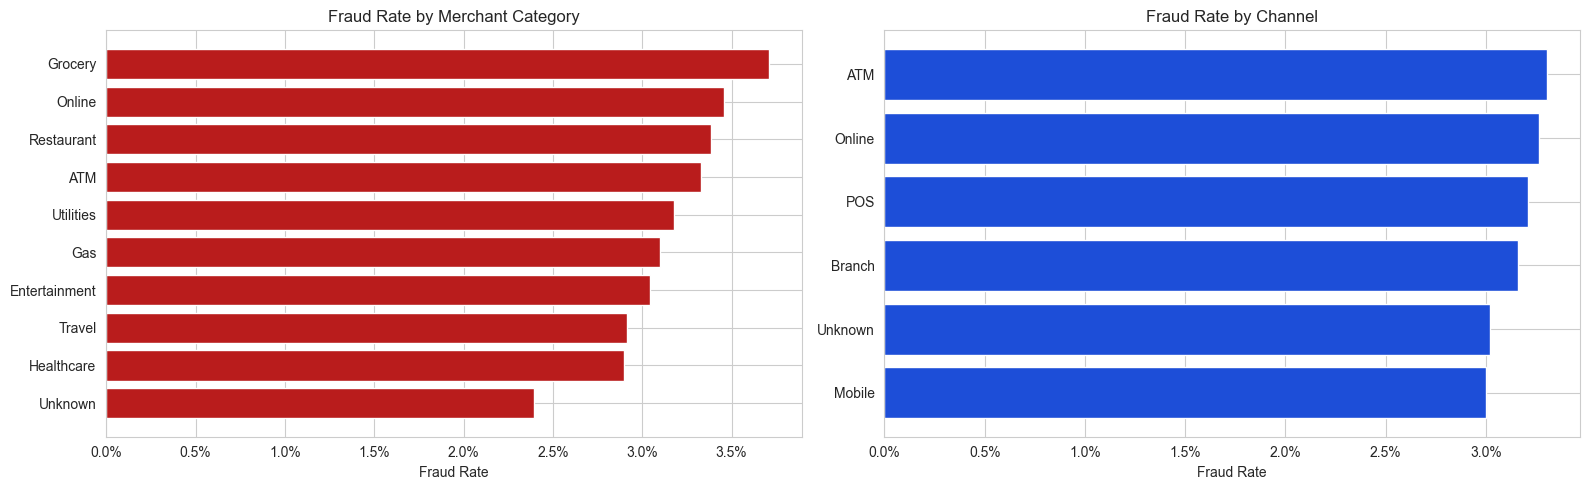

In [6]:
# Cell 5: Visualize fraud rate by merchant category and channel
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if "merchant_category" in fraud_tables:
    top_cat = fraud_tables["merchant_category"].head(10).sort_values("fraud_rate")
    axes[0].barh(top_cat["merchant_category"].astype(str), top_cat["fraud_rate"], color="#b91c1c")
    axes[0].set_title("Fraud Rate by Merchant Category")
    axes[0].set_xlabel("Fraud Rate")
    axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

if "channel" in fraud_tables:
    channel = fraud_tables["channel"].sort_values("fraud_rate")
    axes[1].barh(channel["channel"].astype(str), channel["fraud_rate"], color="#1d4ed8")
    axes[1].set_title("Fraud Rate by Channel")
    axes[1].set_xlabel("Fraud Rate")
    axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

plt.tight_layout()


## Segment Behaviour
Segment profiling compares transaction volume, value, customer count, and fraud rate across customer groups.


In [7]:
# Cell 6: Segment profile
segment_profile = df.groupby("segment", dropna=False).agg(
    transaction_count=("transaction_id", "count"),
    unique_customers=("customer_id", "nunique"),
    total_amount=(amount_col, "sum"),
    avg_amount=(amount_col, "mean"),
    median_amount=(amount_col, "median"),
    max_amount=(amount_col, "max"),
    fraud_count=("is_fraud", "sum"),
).reset_index()
segment_profile["fraud_rate"] = segment_profile["fraud_count"] / segment_profile["transaction_count"]
segment_profile["amount_per_customer"] = segment_profile["total_amount"] / segment_profile["unique_customers"]
segment_profile = segment_profile.sort_values("transaction_count", ascending=False)

display(segment_profile)
segment_profile.to_csv(REPORTS_DIR / "segment_profile.csv", index=False)


,segment,transaction_count,unique_customers,total_amount,avg_amount,median_amount,max_amount,fraud_count,fraud_rate,amount_per_customer
4,Student,17905,1630,6048549.35,337.813424,52.88,999999.00,554,0.030941,3710.766472
1,Premium,17579,1591,2857976.15,162.578995,56.06,9352.19,588,0.033449,1796.339503
3,Senior,17554,1642,2981585.99,169.852227,55.89,19719.37,560,0.031902,1815.825816
2,Retail,16969,1546,2967876.63,174.899913,53.55,20201.18,544,0.032058,1919.713215
0,Business,16571,1573,6795984.67,410.113130,54.04,999999.00,509,0.030716,4320.397120


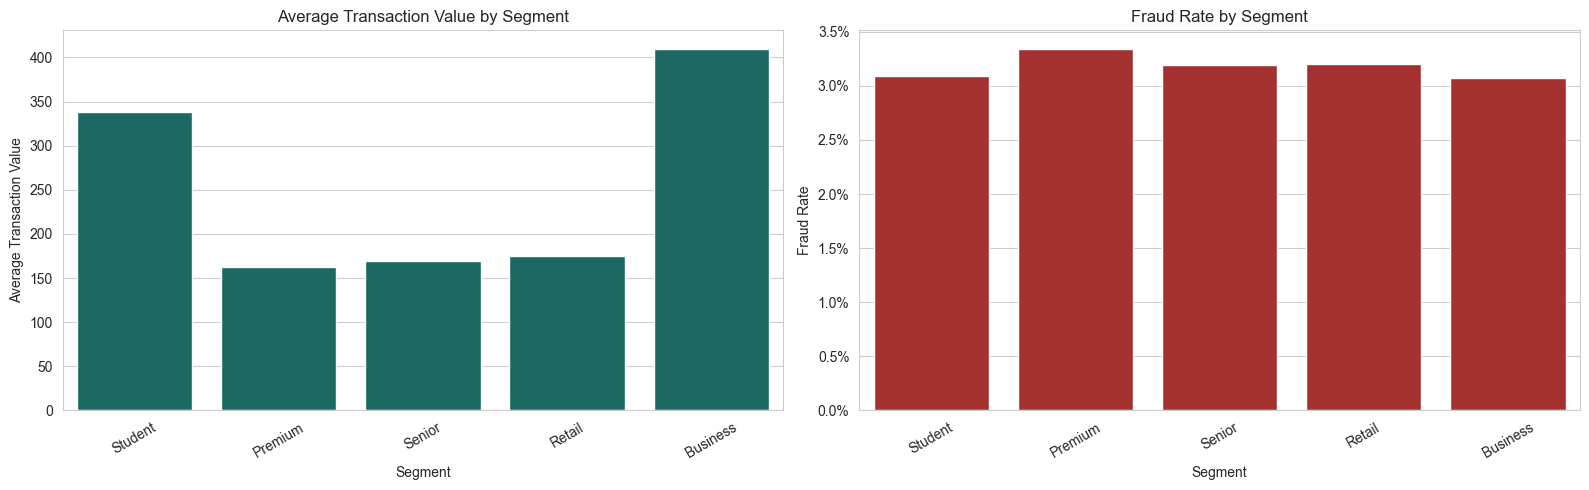

In [8]:
# Cell 7: Segment visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=segment_profile, x="segment", y="avg_amount", ax=axes[0], color="#0f766e")
axes[0].set_title("Average Transaction Value by Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Average Transaction Value")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=segment_profile, x="segment", y="fraud_rate", ax=axes[1], color="#b91c1c")
axes[1].set_title("Fraud Rate by Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Fraud Rate")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()


## Chi-square Independence Test
This tests whether fraud is independent of `merchant_category`. If p-value < 0.05, fraud and merchant category are statistically associated.


In [9]:
# Cell 8: Chi-square test for fraud vs merchant category
contingency = pd.crosstab(df["merchant_category"], df["is_fraud"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

chi_square_result = {
    "chi2": chi2,
    "p_value": p_value,
    "degrees_of_freedom": dof,
    "significant_at_0_05": p_value < 0.05,
}
chi_square_result


{'chi2': 25.853311042807917,
 'p_value': 0.0021589685767314046,
 'degrees_of_freedom': 9,
 'significant_at_0_05': True}

## Transaction Amount Anomalies
A transaction is an amount anomaly when both IQR and Z-score agree. The notebook also flags fraud rows with normal-looking amounts because those are harder to detect from value alone.


In [10]:
# Cell 9: IQR + Z-score anomaly detection
values = pd.to_numeric(df[amount_col], errors="coerce")

q1 = values.quantile(0.25)
q3 = values.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

mean = values.mean()
std = values.std(ddof=0)
z_score = (values - mean) / std if std else pd.Series(0, index=df.index)

analysis = df.copy()
analysis["amount_iqr_outlier"] = (values < lower) | (values > upper)
analysis["amount_z_score"] = z_score
analysis["amount_z_outlier"] = z_score.abs() > 3
analysis["amount_anomaly"] = analysis["amount_iqr_outlier"] & analysis["amount_z_outlier"]
analysis["fraud_with_normal_amount"] = analysis["is_fraud"] & ~analysis["amount_anomaly"]
analysis["suspicious_amount_not_marked_fraud"] = analysis["amount_anomaly"] & ~analysis["is_fraud"]

anomalies = analysis[
    analysis["amount_anomaly"]
    | analysis["fraud_with_normal_amount"]
    | analysis["suspicious_amount_not_marked_fraud"]
].copy()

print(f"IQR bounds: {lower:,.2f} to {upper:,.2f}")
print(f"Amount anomalies: {int(analysis['amount_anomaly'].sum()):,}")
print(f"Fraud with normal amount: {int(analysis['fraud_with_normal_amount'].sum()):,}")
print(f"Suspicious amount not marked fraud: {int(analysis['suspicious_amount_not_marked_fraud'].sum()):,}")
print(f"Total rows exported to anomalies.csv: {len(anomalies):,}")

display(anomalies.head(20))


IQR bounds: -176.68 to 347.32
Amount anomalies: 9
Fraud with normal amount: 2,755
Suspicious amount not marked fraud: 9
Total rows exported to anomalies.csv: 2,764


,transaction_id,account_id,customer_id,transaction_date,transaction_time,amount,transaction_type,merchant_name,merchant_category,channel,...,_source_system,_processed_at,_pipeline_version,transaction_hour,amount_iqr_outlier,amount_z_score,amount_z_outlier,amount_anomaly,fraud_with_normal_amount,suspicious_amount_not_marked_fraud
53,30504,1883,794,2024-12-31,05:28,26.36,Transfer,Uber,Restaurant,Branch,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,5,False,-0.024847,False,False,True,False
54,30504,1883,794,2024-12-31,05:28,26.36,Transfer,Uber,Restaurant,Branch,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,5,False,-0.024847,False,False,True,False
55,30504,1883,794,2024-12-31,05:28,26.36,Transfer,Uber,Restaurant,Branch,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,5,False,-0.024847,False,False,True,False
91,46558,3117,115,2024-12-30,17:23,4.42,Credit,Netflix,Online,Mobile,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,17,False,-0.027283,False,False,True,False
92,46558,3117,115,2024-12-30,17:23,4.42,Credit,Netflix,Online,Mobile,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,17,False,-0.027283,False,False,True,False
94,46558,3117,115,2024-12-30,17:23,4.42,Credit,Netflix,Online,Mobile,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,17,False,-0.027283,False,False,True,False
280,37727,8665,6321,2024-12-28,14:09,161.68,Transfer,Netflix,Unknown,Mobile,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,14,False,-0.009818,False,False,True,False
288,25383,6770,4507,2024-12-28,01:02,149.49,Payment,Target,Entertainment,Online,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,1,False,-0.011172,False,False,True,False
298,25383,6770,4507,2024-12-28,01:02,149.49,Payment,Target,Entertainment,Online,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,1,False,-0.011172,False,False,True,False
299,25383,6770,4507,2024-12-28,01:02,149.49,Payment,Target,Entertainment,Online,...,nexbank_sql_extractor,2026-05-20T23:19:08,1.0.0,1,False,-0.011172,False,False,True,False


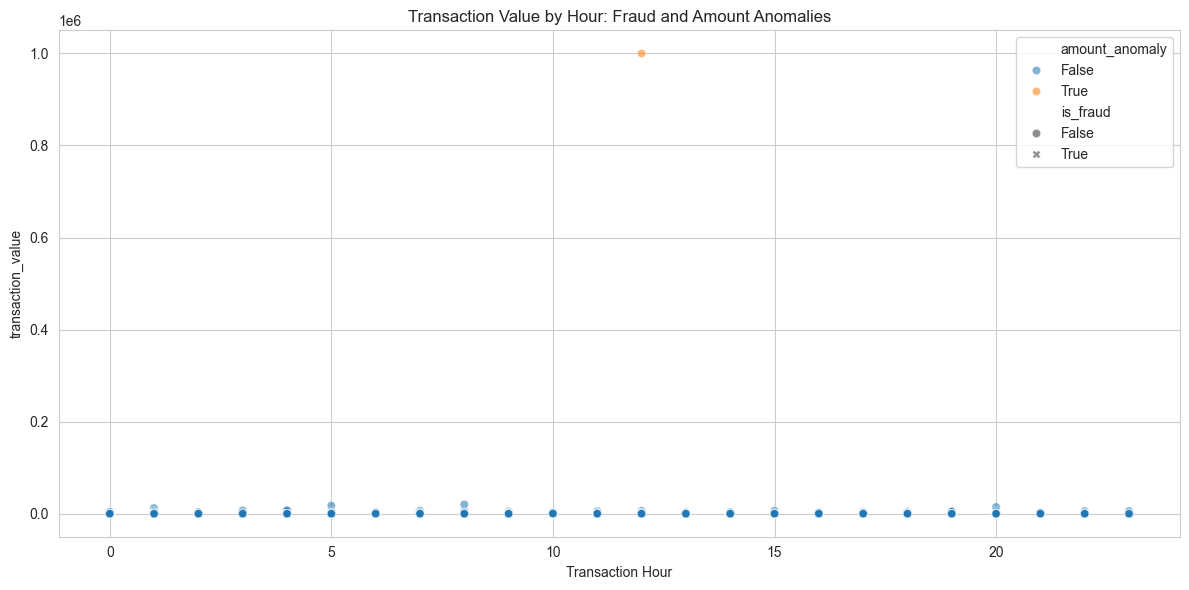

In [11]:
# Cell 10: Visualize transaction amount anomalies
sample = analysis.sample(min(len(analysis), 20000), random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=sample,
    x="transaction_hour",
    y=amount_col,
    hue="amount_anomaly",
    style="is_fraud",
    alpha=0.55,
    ax=ax,
)
ax.set_title("Transaction Value by Hour: Fraud and Amount Anomalies")
ax.set_xlabel("Transaction Hour")
ax.set_ylabel(amount_col)
plt.tight_layout()


In [13]:
# Cell 11: Save report outputs
anomalies.to_csv(REPORTS_DIR / "anomalies.csv", index=False)

report_lines = [
    "NEXBANK BANKING EDA REPORT",
    "=" * 60,
    f"Data source: {DATA_PATH}",
    f"Rows analyzed: {len(df):,}",
    f"Unique transactions: {df['transaction_id'].nunique():,}",
    f"Unique customers: {df['customer_id'].nunique():,}",
    f"Fraud rows: {int(df['is_fraud'].sum()):,}",
    f"Fraud rate: {df['is_fraud'].mean():.2%}",
    "",
    "CHI-SQUARE TEST",
    f"Chi-square statistic: {chi2:.4f}",
    f"p-value: {p_value:.6f}",
    f"Degrees of freedom: {dof}",
    f"Significant at alpha=0.05: {p_value < 0.05}",
    "",
    "ANOMALY SUMMARY",
    f"Amount anomalies: {int(analysis['amount_anomaly'].sum()):,}",
    f"Fraud with normal amount: {int(analysis['fraud_with_normal_amount'].sum()):,}",
    f"Suspicious amount not marked fraud: {int(analysis['suspicious_amount_not_marked_fraud'].sum()):,}",
    f"Total anomaly export rows: {len(anomalies):,}",
    "",
    "TOP MERCHANT CATEGORY FRAUD CONCENTRATIONS",
    fraud_tables["merchant_category"].head(10).to_string(index=False) if "merchant_category" in fraud_tables else "Not available",
    "",
    "SEGMENT PROFILE",
    segment_profile.to_string(index=False),
]

(REPORTS_DIR / "analysis_report.txt").write_text("".join(report_lines), encoding="utf-8")

print("Saved:")
print(REPORTS_DIR / "analysis_report.txt")
print(REPORTS_DIR / "anomalies.csv")
print(REPORTS_DIR / "segment_profile.csv")


Saved:
C:\banking-eda\reports\analysis_report.txt
C:\banking-eda\reports\anomalies.csv
C:\banking-eda\reports\segment_profile.csv


## Summary and Next Steps

After running the notebook, use the generated report files in `reports/` for your project submission.

### Key findings to record
| Finding | Value | Action |
|---|---:|---|
| Highest fraud merchant category | Fill after Cell 4 | Review controls |
| Highest fraud customer segment | Fill after Cell 6 | Segment monitoring |
| Chi-square significant? | Fill after Cell 8 | Use as evidence |
| Total anomaly export rows | Fill after Cell 9 | Investigate exceptions |

### Risk questions for NexBank
1. Which merchant categories need tighter monitoring rules?
2. Which customer segments show high transaction value or high fraud rates?
3. Which fraud transactions are hardest to catch because their amounts look normal?
